In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt


import pyccl as ccl
import sys
sys.path.append('../forecasts/')
import cosmology
import fisher_matrix_bao_SuEisenstein

import _tracer_spectroscopic_efficiency
import _survey_design_telescope_metrics
import _surveys
import _survey_design_science_metrics
# params = {
#     "font.family": "serif",
#     "font.serif": ["Times", "Times New Roman", "DejaVu Serif"],
#     "axes.labelsize": 10,
#     "font.size": 10,
#     "legend.fontsize": 8,
#     "xtick.labelsize": 8,
#     "ytick.labelsize": 8,
#     "text.usetex": True,
#     "figure.figsize": [3.386, 3.386],
#     "figure.dpi": 300,
#     "savefig.bbox": "tight",
#     "savefig.pad_inches": 0.05,
#     "axes.linewidth": 0.8,
#     "xtick.major.width": 0.8,
#     "ytick.major.width": 0.8,
#     "xtick.direction": "in",
#     "ytick.direction": "in",
#     "xtick.top": True,
#     "ytick.right": True,
# }
# plt.rcParams.update(params)

In [2]:
import pickle
def save_pickle(dat, filename, **kwargs):
    file = open(filename,'wb')
    pickle.dump(dat, file)
    file.close()
def load(filename, **kwargs):
    with open(filename, 'rb') as fin:
        return pickle.load(fin, **kwargs)

In [3]:
path = './telescope_and_science_metrics/'

In [4]:
survey_design_bright = load(path + 'survey_design_Bright.pkl')
survey_design_grey = load(path + 'survey_design_Grey.pkl')
survey_design_dark = load(path + 'survey_design_Dark.pkl')

In [5]:
m = survey_design_bright['per_tracer_forecasts']['BG_bright_mag_max_eval']
zeff = survey_design_bright['per_tracer_forecasts']['BG_bright_zeff_Da']
sigma_Da_eff = survey_design_bright['per_tracer_forecasts']['BG_bright_sigma_Da_eff']
sigma_H_eff = survey_design_bright['per_tracer_forecasts']['BG_bright_sigma_H_eff']

<Figure size 400x500 with 0 Axes>

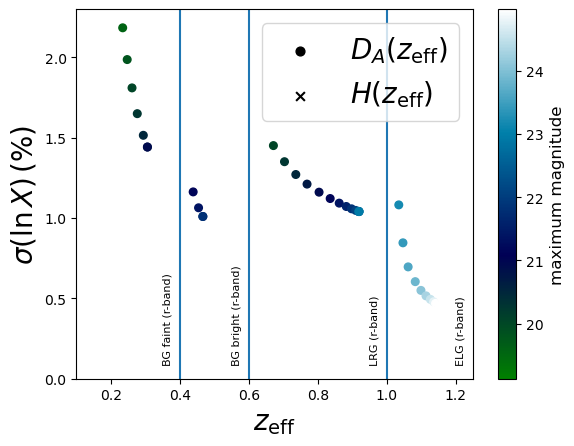

In [8]:

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ----------------------------
# gather ALL color values
# ----------------------------
c_all = np.concatenate([
    survey_design_bright['per_tracer_forecasts']['BG_bright_mag_max_eval'],
    survey_design_grey['per_tracer_forecasts']['BG_faint_mag_max_eval'],
    survey_design_grey['per_tracer_forecasts']['LRG_mag_max_eval'],
    survey_design_grey['per_tracer_forecasts']['ELG_mag_max_eval']
])

# ----------------------------
# shared normalization
# ----------------------------
norm = mpl.colors.Normalize(vmin=c_all.min(), vmax=c_all.max())
cmap = "ocean"
plt.figure(figsize=(4,5))
fig, ax = plt.subplots()

# helper function
def scat(x, y, c,marker):
    return ax.scatter(x, y*100, c=c, ls='-', cmap=cmap, norm=norm, s=30, marker=marker
                     )

# ----------------------------
# bright
# ----------------------------
scat(
    survey_design_bright['per_tracer_forecasts']['BG_bright_zeff_Da'],
    np.array(survey_design_bright['per_tracer_forecasts']['BG_bright_sigma_rsd_eff']),
    survey_design_bright['per_tracer_forecasts']['BG_bright_mag_max_eval'], 'o',
)


# ----------------------------
# faint / grey
# ----------------------------
scat(
    survey_design_grey['per_tracer_forecasts']['BG_faint_zeff_Da'],
    np.array(survey_design_grey['per_tracer_forecasts']['BG_faint_sigma_rsd_eff']),
    survey_design_grey['per_tracer_forecasts']['BG_faint_mag_max_eval'],'o',
)



scat(
    survey_design_grey['per_tracer_forecasts']['LRG_zeff_Da'],
    np.array(survey_design_grey['per_tracer_forecasts']['LRG_sigma_rsd_eff']),
    survey_design_grey['per_tracer_forecasts']['LRG_mag_max_eval'],'o',
)



scat(
    survey_design_grey['per_tracer_forecasts']['ELG_zeff_rsd'],
    np.array(survey_design_grey['per_tracer_forecasts']['ELG_sigma_rsd_eff']),
    survey_design_grey['per_tracer_forecasts']['ELG_mag_max_eval'], 'o',
)



# ----------------------------
# single colorbar
# ----------------------------
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("maximum magnitude", fontsize=12)

ax.set_xlabel(r"$z_{\rm eff}$", fontsize=20)
ax.set_ylabel(r"$\sigma(\ln X) \,(\%)$", fontsize=20)

ax.scatter([], [], marker = 'o', label = r'$D_A(z_{\rm eff})$', s=40, color='k')

ax.scatter([], [], marker = 'x', label = r'$H(z_{\rm eff})$', s=40, color='k')

plt.legend(fontsize=20)

plt.ylim(0, 2.3)
plt.vlines(0.4, -1, 100)
plt.vlines(0.6, -1, 100)
plt.vlines(1, -1, 100)
plt.xlim(0.1, 1.25)
plt.text(0.35, 0.1, 'BG faint (r-band)', size=8, rotation=90)
plt.text(0.55, 0.1, 'BG bright (r-band)', size=8, rotation=90)
plt.text(0.95, 0.1, 'LRG (r-band)', size=8, rotation=90)
plt.text(1.2, 0.1, 'ELG (r-band)', size=8, rotation=90)

plt.show()

In [81]:
h=0.677
deltac=1.686
H0=100*h
c_ls=300*10**3
nlim=10000
n_s=0.968

cosmo = ccl.Cosmology(Omega_c=0.27, Omega_b=0.045, h=h, A_s=2.1e-9, n_s=n_s,transfer_function='boltzmann_camb')

import numpy as np
import pyccl as ccl

def sigma_w0_wa_Om_eff(zeff, sigma_Da_eff, sigma_H_eff, cosmo, w0=-1.0, wa=0.0, corr_DaH=0.0, rel_step=1e-2):
    """
    Propagate effective BAO constraints (sigma_Da_eff, sigma_H_eff) at a single
    effective redshift into marginalised errors on (w0, wa, Omega_m).

    All fiducial distances are computed internally from CCL cosmologies built
    by perturbing the fiducial parameters — no external Jacobian helper needed.

    Parameters
    ----------
    zeff         : float      – effective redshift of the survey
    sigma_Da_eff : float      – 1-sigma fractional (or absolute) error on D_A
    sigma_H_eff  : float      – 1-sigma fractional (or absolute) error on H
    cosmo        : ccl object – fiducial CCL cosmology
    w0, wa       : float      – fiducial dark energy EoS (default: LCDM)
    corr_DaH     : float      – correlation coefficient between D_A and H errors
    rel_step     : float      – relative step size for numerical derivatives

    Returns
    -------
    sigma : dict  {'w0': ..., 'wa': ..., 'Omega_m': ...}  marginalised 1-sigma errors
    F     : (3,3) ndarray  Fisher matrix in (w0, wa, Omega_m) space
    C     : (3,3) ndarray  covariance matrix
    """

    # ------------------------------------------------------------------
    # Extract fiducial parameters from the CCL object
    # ------------------------------------------------------------------
    Omega_m_fid = cosmo['Omega_m']
    Omega_b_fid = cosmo['Omega_b']
    h_fid       = cosmo['h']
    n_s_fid     = cosmo['n_s']
    sigma8_fid  = cosmo['sigma8']

    params_fid = {
        'w0'     : w0,
        'wa'     : wa,
        'Omega_m': Omega_m_fid,
    }

    # ------------------------------------------------------------------
    # Helper: build a CCL cosmology from a parameter dict
    # ------------------------------------------------------------------
    def _make_cosmo(p):
        Om  = p['Omega_m']
        Oc  = Om - Omega_b_fid          # keep Omega_b fixed, vary Omega_cdm
        return ccl.Cosmology(
            Omega_c  = Oc,
            Omega_b  = Omega_b_fid,
            h        = h_fid,
            n_s      = n_s_fid,
            sigma8   = sigma8_fid,
            w0       = p['w0'],
            wa       = p['wa'],
        )

    # ------------------------------------------------------------------
    # Helper: BAO observables (D_A, H) from a CCL cosmology
    # ------------------------------------------------------------------
    def _observables(p):
        c = _make_cosmo(p)
        a = 1.0 / (1.0 + zeff)
        # comoving angular diameter distance [Mpc]
        chi  = ccl.comoving_radial_distance(c, a)   # Mpc
        Da   = chi / (1.0 + zeff)                   # Mpc
        # Hubble parameter [km/s/Mpc]
        H    = ccl.h_over_h0(c, a) * 100.0 * h_fid # km/s/Mpc
        return np.array([Da, H])

    # ------------------------------------------------------------------
    # Numerical Jacobian  J[i,j] = d O_i / d theta_j
    # ------------------------------------------------------------------

    param_names = ('w0', 'wa')
    J = np.zeros((2, len(param_names)))

    for j, par in enumerate(param_names):
        step = rel_step

        p_plus  = dict(params_fid); p_plus[par]  += step
        p_minus = dict(params_fid); p_minus[par] -= step

        J[:, j] = (_observables(p_plus) - _observables(p_minus)) / (2.0 * step)

    # ------------------------------------------------------------------
    # Observational covariance of (D_A, H)
    # ------------------------------------------------------------------
    O_fid = _observables(params_fid)
    Da_fid, H_fid_val = O_fid

    abs_sigma_Da = sigma_Da_eff * Da_fid 
    abs_sigma_H  = sigma_H_eff  * H_fid_val 

    C_obs = np.array([
        [abs_sigma_Da**2, corr_DaH * abs_sigma_Da * abs_sigma_H],
        [corr_DaH * abs_sigma_Da * abs_sigma_H,  abs_sigma_H**2],])
    C_obs_inv = np.linalg.inv(C_obs)

    F = J.T @ C_obs_inv @ J
    print(F)
    C = np.linalg.inv(F)

    sigma = {
        'w0'     : np.sqrt(C[0, 0]),
        'wa'     : np.sqrt(C[1, 1]),
        'Omega_m': np.sqrt(C[2, 2]),
    }

    return sigma, F, C
m = survey_design_bright['per_tracer_forecasts']['BG_bright_mag_max_eval']
zeff = survey_design_bright['per_tracer_forecasts']['BG_bright_zeff_Da']
sigma_Da_eff = survey_design_bright['per_tracer_forecasts']['BG_bright_sigma_Da_eff']
sigma_H_eff = survey_design_bright['per_tracer_forecasts']['BG_bright_sigma_H_eff']

for i in range(len(m)):
    sigma, F, C = sigma_w0_wa_Om_eff(zeff[i], sigma_Da_eff[i], sigma_H_eff[i], cosmo, corr_DaH=0.0)
    plt.scatter(m[i], sigma['w0'])
    plt.scatter(m[i], sigma['wa'])

[[124.68094439   9.39634842]
 [  9.39634842   0.7355951 ]]


IndexError: index 2 is out of bounds for axis 0 with size 2

In [25]:
sigma

{'w0': np.float64(0.46354844539538137), 'wa': np.float64(6.034978896307374)}

In [9]:
plt.plot(survey_design_bright['per_tracer_FnP']['BG_faint_nP_eff_k0.001'], 'k')
plt.plot(survey_design_bright['per_tracer_FnP']['LBGg_nP_eff_k0.001'], 'm')
plt.plot(survey_design_bright['per_tracer_FnP']['LBGr_nP_eff_k0.001'], 'g')

KeyError: 'BG_faint_nP_eff_k0.001'

In [ ]:
mat_FnP_k1 = survey_design_dark['total_survey_Informations']['total_survey_information_FnP_k1']

In [ ]:
for k in [0.001]:
    mat_FnP_k = survey_design_grey[f'total_survey_Informations'][f'total_survey_information_FnP_k{k}']
    plt.plot( mat_FnP_k[:,0,0], 'k')
    plt.plot(mat_FnP_k[0,:,0], 'm')
    plt.plot(mat_FnP_k[0,0,:], 'g')


In [ ]:
survey_design_bright[ 'per_tracer_forecasts'].keys()

In [ ]:
for survey in [survey_design_dark]:
    for i, tracer in enumerate(survey['config_survey']['tracers']):
        plt.plot(survey['config_survey'][tracer + '_mag_centers'], np.array(survey[ 'per_tracer_forecasts'][tracer + '_sigma_fnl_eff']), 
                 color = survey['config_survey']['color'][i], label = survey['config_survey']['survey_type'] + ' ' + tracer)
        
        #plt.plot(survey['config_survey'][tracer + '_mag_centers'], 100**np.array(survey[ 'per_tracer_forecasts'][tracer + '_sigma_rsd_eff']), 
        #         ls='--', color = survey['config_survey']['color'][i], label = survey['config_survey']['survey_type'] + ' ' + tracer)
plt.legend()
plt.grid()
plt.xlabel(r'$\sigma(\sum M_\nu)$', fontsize=20)

#plt.xlim(100, 0)

In [ ]:
for survey in [survey_design_dark]:
    sigma_Da_target = 0.0006
    sigma_fnl_target = 1.1
    plt.figure(figsize=(5,4))
    Information_fnl = survey['total_survey_Informations']['total_survey_fisher_information_fnl']
    Information_Da = survey['total_survey_Informations']['total_survey_fisher_information_Da']
    Information_Mnu = survey['total_survey_Informations']['total_survey_fisher_information_Mnu']
    Information_rsd = survey['total_survey_Informations']['total_survey_fisher_information_rsd']
    total_time= survey['total_survey_Informations']['total_survey_time']
    total_survey_efficiency = survey['total_survey_Informations']['total_survey_efficiency']
    
    FoM_all = (sigma_fnl_target **2 * Information_fnl + sigma_Da_target **2 * Information_Da)
    FoM_fnl = sigma_fnl_target **2 * Information_fnl
    FoM_Da = sigma_Da_target **2 * Information_Da
    plt.title(survey['config_survey']['survey_type'])
    x = 2*np.random.random(len(total_time.flatten())) -1
    #plt.scatter(total_time.flatten() + 0.2*x*np.linspace(-1, 1, len(total_time.flatten())),  1/Information_fnl**.5,c= total_survey_efficiency.flatten(), s=10, label = 'Combined', cmap='jet', vmax=1, vmin=0.4)
    plt.scatter(total_time.flatten() + 0.2*x*np.linspace(-1, 1, len(total_time.flatten())),  1/Information_rsd**.5,c= total_survey_efficiency.flatten(), s=10, 
                label = 'Combined', cmap='jet', vmax=0.6, vmin=0.4)
    #plt.scatter(total_time.flatten() + 0.2*x*np.linspace(-1, 1, len(total_time.flatten())),  100*1/Information_rsd**.5,c= total_survey_efficiency.flatten(), s=10, label = 'Combined', cmap='jet', vmax=1, vmin=0.4)
    plt.ylabel(r'$\sigma(f_{\rm NL}^{\rm loc})$', fontsize=20)
    plt.ylabel(r'$\sigma(f_{\rm NL}^{\rm loc})$', fontsize=20)
    plt.xlabel(r'Scenario total time (years)', fontsize=10)
    cbar = plt.colorbar()
    cbar.set_label(r'$n_{\rm spec}/n_{\rm target}$', fontsize=20)
    plt.xlim(0, 7)

In [ ]:
for survey in [ survey_design_dark,]:

    plt.figure(figsize=(6,4))

    Information_fnl = survey['total_survey_Informations']['total_survey_fisher_information_fnl']
    Information_Da = survey['total_survey_Informations']['total_survey_fisher_information_Da']
    Information_Mnu = survey['total_survey_Informations']['total_survey_fisher_information_Mnu']
    Information_rsd = survey['total_survey_Informations']['total_survey_fisher_information_rsd']

    colors = [
    "#332288",  # dark blue
    "#88CCEE",  # light blue
    "#44AA99",  # teal
    "#117733",  # green
    "#999933",  # olive
    "#DDCC77",  # sand
    "#CC6677",  # rose
    "#882255",  # wine
    "#AA4499",  # magenta
    "#661100",  # dark brown
    ]

    Informations = [
        Information_fnl,
        Information_Da / (100**2),
        Information_Mnu / (1000**2),
        Information_rsd / (100**2),
    ]

    labels = [r'$\sigma(f_{\rm NL}^{\rm loc})$', r'$\sigma(\ln D_A) (\%)$', r'$\sigma(M_\nu)$[meV]', r'$\sigma(\ln f\sigma_8) (\%)$']
    error_base = [1.3, 0.07, 20, 1]

    total_time = survey['total_survey_Informations']['total_survey_time']
    total_survey_efficiency = survey['total_survey_Informations']['total_survey_efficiency']

    plt.title(survey['config_survey']['survey_type'])

    unique_total_time = np.unique(total_time)

    for k, info in enumerate(Informations):

        times = []
        errors = []
        efficiency = []

        for t_survey in unique_total_time:

            mask_time = total_time.flatten() == t_survey

            error = 1 / np.sqrt(info.flatten()[mask_time])
            efficiency_ = total_survey_efficiency.flatten()[mask_time]


            best_idx = np.argmin(error)
            best_idx = np.argmax(efficiency_)

            times.append(t_survey)
            errors.append(error[best_idx])
            efficiency.append(efficiency_[best_idx])

        plt.plot(times,np.array( errors )/error_base[k], '-p', color=colors[k], label=labels[k] +F' ref: ${error_base[k]:.2F}$')
        #if k ==0: plt.plot(times, efficiency, '--',color=colors[k], label = r'$n_{\rm spec}/n_{\rm target}$')
    plt.plot(times, efficiency, '--',color='k', label = r'$n_{\rm spec}/n_{\rm target}$')
    plt.legend(ncols=2)
    plt.xlabel(r'Scenario total time (years)', fontsize=14)
    plt.grid()
    plt.ylabel(r'$\sigma$(param)/$\sigma$(ref)', fontsize=14)
    #plt.xlim(0, 7)
    plt.ylim(0.25, 1.4)